<a href="https://colab.research.google.com/github/dang710206/btap-AI---week-2/blob/main/bt11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.1 MB/s eta 0:00:00


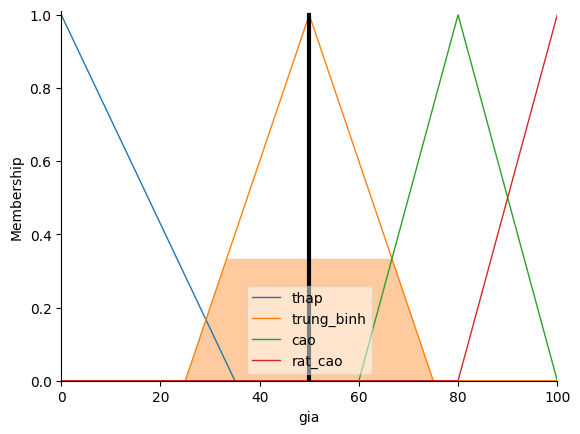

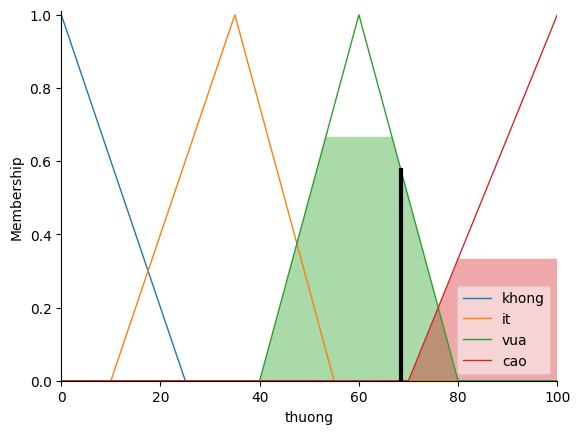

In [5]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

khoang_cach = ctrl.Antecedent(np.arange(0, 51, 1), 'khoang_cach')
giao_thong = ctrl.Antecedent(np.arange(0, 101, 1), 'giao_thong')
nhu_cau = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau')
thoi_tiet = ctrl.Antecedent(np.arange(0, 101, 1), 'thoi_tiet')
danh_gia = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'danh_gia')
dung_gio = ctrl.Antecedent(np.arange(0, 101, 1), 'dung_gio')

gia = ctrl.Consequent(np.arange(0, 101, 1), 'gia')
thuong = ctrl.Consequent(np.arange(0, 101, 1), 'thuong')

khoang_cach['ngan'] = fuzz.trimf(khoang_cach.universe, [0, 0, 3])
khoang_cach['trung_binh'] = fuzz.trimf(khoang_cach.universe, [2, 8, 20])
khoang_cach['xa'] = fuzz.trimf(khoang_cach.universe, [6, 20, 50])
khoang_cach['rat_xa'] = fuzz.trimf(khoang_cach.universe, [15, 35, 50])

giao_thong['thap'] = fuzz.trimf(giao_thong.universe, [0, 0, 30])
giao_thong['trung_binh'] = fuzz.trimf(giao_thong.universe, [20, 50, 70])
giao_thong['cao'] = fuzz.trimf(giao_thong.universe, [60, 100, 100])

nhu_cau['thap'] = fuzz.trimf(nhu_cau.universe, [0, 0, 30])
nhu_cau['trung_binh'] = fuzz.trimf(nhu_cau.universe, [20, 50, 70])
nhu_cau['cao'] = fuzz.trimf(nhu_cau.universe, [60, 100, 100])

thoi_tiet['tot'] = fuzz.trimf(thoi_tiet.universe, [0, 0, 30])
thoi_tiet['binh_thuong'] = fuzz.trimf(thoi_tiet.universe, [20, 50, 80])
thoi_tiet['xau'] = fuzz.trimf(thoi_tiet.universe, [60, 100, 100])

danh_gia['kem'] = fuzz.trimf(danh_gia.universe, [1, 1, 2.5])
danh_gia['trung_binh'] = fuzz.trimf(danh_gia.universe, [2, 3.5, 4])
danh_gia['tot'] = fuzz.trimf(danh_gia.universe, [3.5, 5, 5])

dung_gio['tre'] = fuzz.trimf(dung_gio.universe, [0, 0, 50])
dung_gio['dung'] = fuzz.trimf(dung_gio.universe, [40, 60, 80])
dung_gio['som'] = fuzz.trimf(dung_gio.universe, [70, 100, 100])

gia['thap'] = fuzz.trimf(gia.universe, [0, 0, 35])
gia['trung_binh'] = fuzz.trimf(gia.universe, [25, 50, 75])
gia['cao'] = fuzz.trimf(gia.universe, [60, 80, 100])
gia['rat_cao'] = fuzz.trimf(gia.universe, [80, 100, 100])

thuong['khong'] = fuzz.trimf(thuong.universe, [0, 0, 25])
thuong['it'] = fuzz.trimf(thuong.universe, [10, 35, 55])
thuong['vua'] = fuzz.trimf(thuong.universe, [40, 60, 80])
thuong['cao'] = fuzz.trimf(thuong.universe, [70, 100, 100])

rule1 = ctrl.Rule(khoang_cach['ngan'] & giao_thong['thap'] & nhu_cau['thap'], gia['thap'])
rule2 = ctrl.Rule(khoang_cach['ngan'] & giao_thong['trung_binh'] & nhu_cau['cao'], gia['trung_binh'])
rule3 = ctrl.Rule(khoang_cach['trung_binh'] & giao_thong['cao'] & nhu_cau['cao'], gia['cao'])
rule4 = ctrl.Rule(khoang_cach['xa'] & giao_thong['trung_binh'] & thoi_tiet['tot'], gia['trung_binh'])
rule5 = ctrl.Rule(khoang_cach['xa'] & giao_thong['cao'] & thoi_tiet['xau'], gia['rat_cao'])
rule6 = ctrl.Rule(khoang_cach['rat_xa'] & giao_thong['cao'] & nhu_cau['cao'], gia['rat_cao'])
rule7 = ctrl.Rule(khoang_cach['trung_binh'] & giao_thong['thap'] & nhu_cau['thap'], gia['trung_binh'])
rule8 = ctrl.Rule(khoang_cach['ngan'] & nhu_cau['cao'] & thoi_tiet['xau'], gia['cao'])
rule9 = ctrl.Rule(khoang_cach['rat_xa'] & thoi_tiet['xau'], gia['rat_cao'])
rule10 = ctrl.Rule(khoang_cach['trung_binh'] & giao_thong['trung_binh'] & thoi_tiet['binh_thuong'], gia['trung_binh'])

rule11 = ctrl.Rule(danh_gia['tot'] & dung_gio['som'], thuong['cao'])
rule12 = ctrl.Rule(danh_gia['trung_binh'] & dung_gio['dung'], thuong['vua'])
rule13 = ctrl.Rule(danh_gia['kem'] & dung_gio['tre'], thuong['khong'])
rule14 = ctrl.Rule(khoang_cach['xa'] & giao_thong['cao'] & dung_gio['dung'], thuong['cao'])
rule15 = ctrl.Rule(khoang_cach['trung_binh'] & giao_thong['trung_binh'] & danh_gia['tot'], thuong['vua'])
rule16 = ctrl.Rule(danh_gia['kem'] & dung_gio['tre'], thuong['khong'])
rule17 = ctrl.Rule(khoang_cach['rat_xa'] & thoi_tiet['xau'] & danh_gia['tot'], thuong['cao'])
rule18 = ctrl.Rule(khoang_cach['ngan'] & danh_gia['trung_binh'] & dung_gio['dung'], thuong['it'])
rule19 = ctrl.Rule(khoang_cach['xa'] & giao_thong['cao'] & dung_gio['tre'], thuong['it'])
rule20 = ctrl.Rule(khoang_cach['trung_binh'] & thoi_tiet['binh_thuong'] & danh_gia['tot'], thuong['vua'])

rules = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
         rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20]

grab_ctrl = ctrl.ControlSystem(rules)
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)

grab_sim.input['khoang_cach'] = 12
grab_sim.input['giao_thong'] = 50
grab_sim.input['nhu_cau'] = 30
grab_sim.input['thoi_tiet'] = 20
grab_sim.input['danh_gia'] = 4.6
grab_sim.input['dung_gio'] = 80

grab_sim.compute()

gia.view(sim=grab_sim)
thuong.view(sim=grab_sim)
plt.show()
